In [3]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict

In [2]:
load_dotenv()  

False

In [4]:
class BatsmanState(TypedDict):
    runs : int
    ball : int
    fours : int
    sixes : int

    strike_rate : float
    balls_per_boundary : float
    boundary_percentage : float
    summary : str

In [5]:
graph = StateGraph(BatsmanState)

In [7]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    strike_rate = (state["runs"] / state["ball"]) * 100 if state["ball"] > 0 else 0
    return {'strike_rate': strike_rate}

In [8]:
def calculate_balls_per_boundary(state: BatsmanState) -> BatsmanState:
    total_boundaries = state["fours"] + state["sixes"]
    balls_per_boundary = (state["ball"] / total_boundaries) if total_boundaries > 0 else 0
    return {'balls_per_boundary': round(balls_per_boundary, 2)}

In [9]:
def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:
    boundary_percentage = ((state["fours"] + state["sixes"]) / state["ball"]) * 100 if state["ball"] > 0 else 0
    return {'boundary_percentage': round(boundary_percentage, 2)}

In [10]:
def get_batsman_summary(state: BatsmanState) -> str:
    summary = f"""
    Strike Rate - {state['strike_rate']} \n
    Balls per boundary - {state['balls_per_boundary']} \n
    Boundary percent - {state['boundary_percentage']}
    """
    
    return {'summary': summary}

In [11]:
graph.add_node('strike_rate', calculate_strike_rate)
graph.add_node('balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('boundary_percentage', calculate_boundary_percentage)

graph.add_edge(START, 'strike_rate')
graph.add_edge(START, 'balls_per_boundary')
graph.add_edge(START, 'boundary_percentage')

graph.add_node('summary', get_batsman_summary)

graph.add_edge('strike_rate', 'summary')
graph.add_edge('balls_per_boundary', 'summary')
graph.add_edge('boundary_percentage', 'summary')

graph.add_edge('summary', END)


In [12]:
workflow = graph.compile()

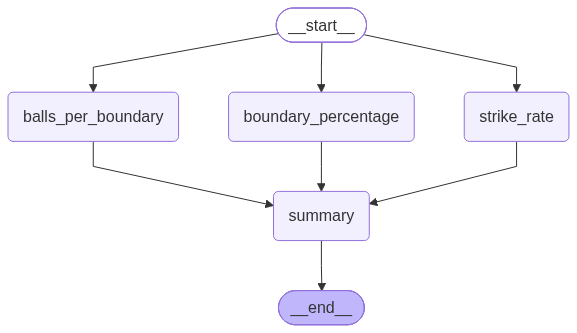

In [13]:
workflow

In [14]:
initial_state = {
    "runs": 100,
    "ball": 60,
    "fours": 10,
    "sixes": 5
    }


#invoke
final_state = workflow.invoke(initial_state)

In [15]:
print(final_state)

{'runs': 100, 'ball': 60, 'fours': 10, 'sixes': 5, 'strike_rate': 166.66666666666669, 'balls_per_boundary': 4.0, 'boundary_percentage': 25.0, 'summary': '\n    Strike Rate - 166.66666666666669 \n\n    Balls per boundary - 4.0 \n\n    Boundary percent - 25.0\n    '}


In [ ]:
"""
here if you observe we are only returning single value as map from each node because, 
in the parallel workflow while we are connecting the summary node the three nodes 
are pointing to the summary nodes and it thinks the different states from each node 
and hence through error. So to avoid that we are returning single value as map from 
each node and then connecting to the summary node.

"""